In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [3]:
df = pd.read_csv("linkedin_jobs_Last.csv")

In [4]:
sns.set_theme(style="whitegrid", font_scale=1.0)

In [5]:
skills = ["python", "sql", "excel", "power_bi", "tableau", "aws", "sap", "statistics", "power_query", "dax"]

In [11]:
def add_values(ax):
    for container in ax.containers:
        ax.bar_label(container, fmt="%.0f", padding=3)

In [12]:
skill_count = df[skills].eq("Yes").sum().sort_values(ascending=False)

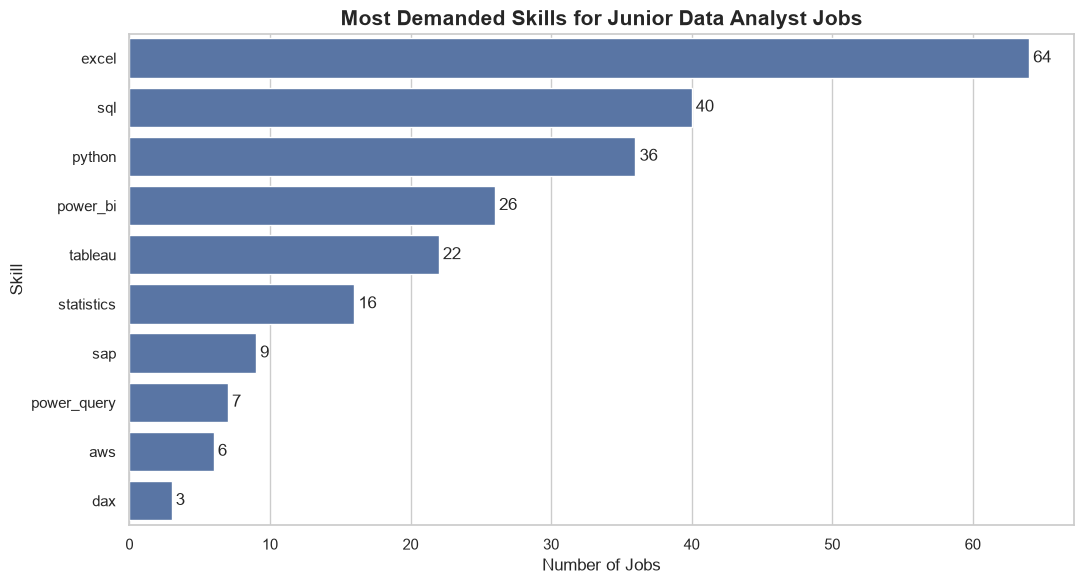

In [13]:
plt.figure(figsize=(11, 6))
ax = sns.barplot(x=skill_count.values, y=skill_count.index)
add_values(ax)
plt.title("Most Demanded Skills for Junior Data Analyst Jobs", fontsize=15, fontweight="bold")
plt.xlabel("Number of Jobs")
plt.ylabel("Skill")
plt.tight_layout()
plt.show()

In [14]:
skill_percentage = df[skills].eq("Yes").mean().mul(100).sort_values(ascending=False)

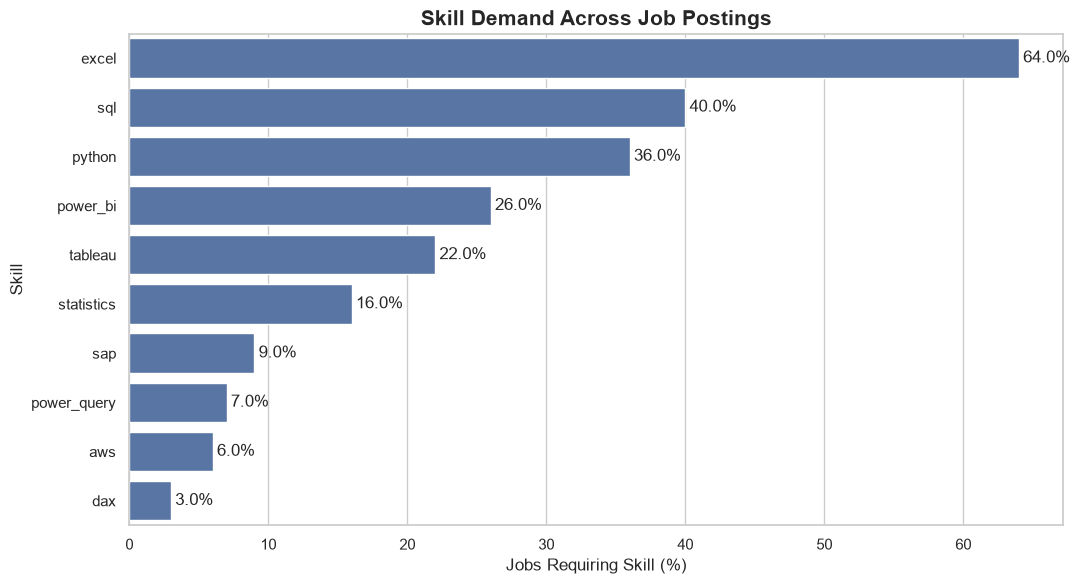

In [15]:
plt.figure(figsize=(11, 6))
ax = sns.barplot(x=skill_percentage.values, y=skill_percentage.index)
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3)
plt.title("Skill Demand Across Job Postings", fontsize=15, fontweight="bold")
plt.xlabel("Jobs Requiring Skill (%)")
plt.ylabel("Skill")
plt.tight_layout()
plt.show()

In [16]:
skill_binary = df[skills].eq("Yes").astype(int)

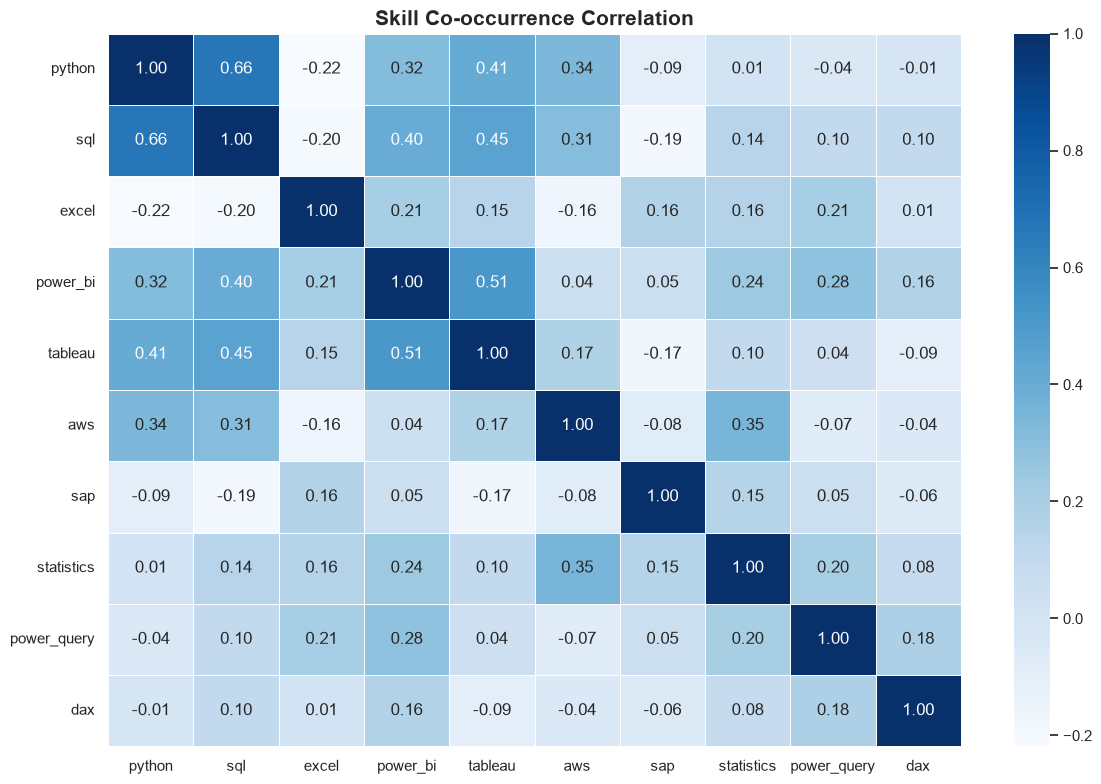

In [17]:
plt.figure(figsize=(12, 8))
sns.heatmap(
    skill_binary.corr(),
    annot=True,
    fmt=".2f",
    cmap="Blues",
    linewidths=0.5
)
plt.title("Skill Co-occurrence Correlation", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

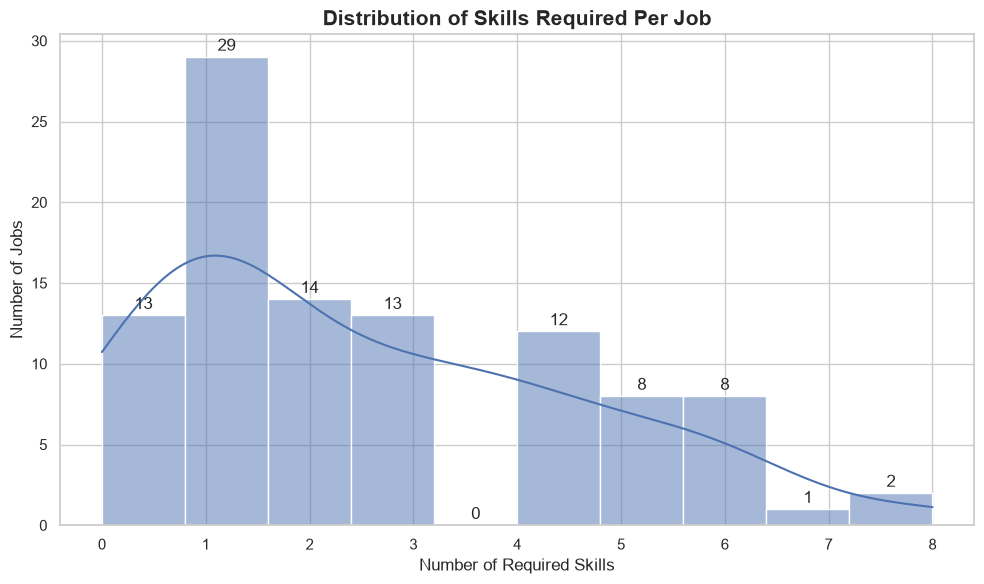

In [18]:
plt.figure(figsize=(10, 6))
ax = sns.histplot(
    data=df,
    x="skill_count",
    bins=10,
    kde=True
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", padding=2)

plt.title("Distribution of Skills Required Per Job", fontsize=15, fontweight="bold")
plt.xlabel("Number of Required Skills")
plt.ylabel("Number of Jobs")
plt.tight_layout()
plt.show()

In [19]:
top_companies = df["company"].value_counts().head(10).sort_values()

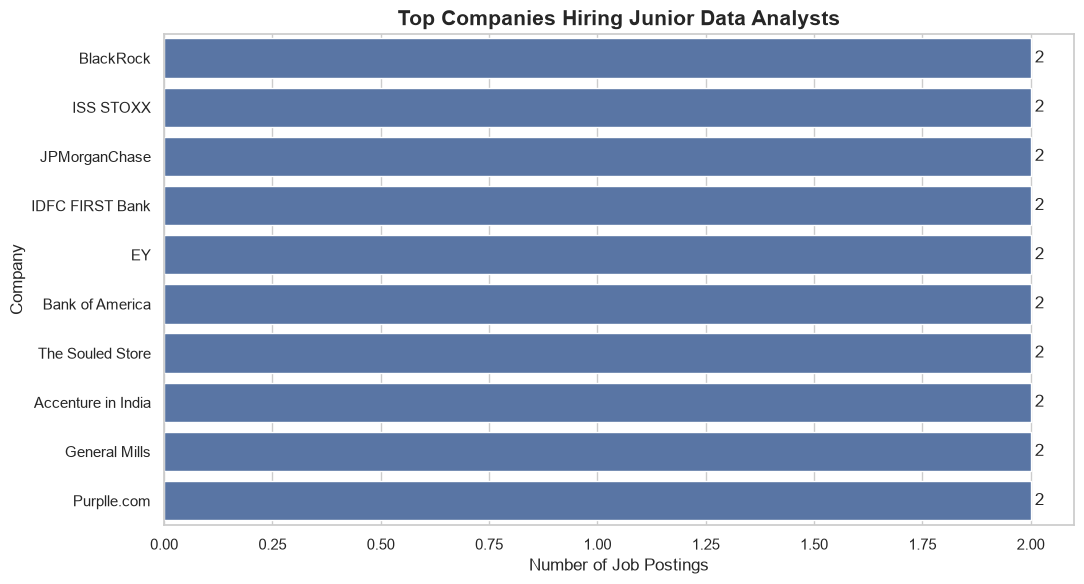

In [20]:
plt.figure(figsize=(11, 6))
ax = sns.barplot(
    x=top_companies.values,
    y=top_companies.index
)

add_values(ax)

plt.title("Top Companies Hiring Junior Data Analysts", fontsize=15, fontweight="bold")
plt.xlabel("Number of Job Postings")
plt.ylabel("Company")
plt.tight_layout()
plt.show()

In [22]:
work_mode = pd.Series({
    "Remote": (df["remote"] == "Yes").sum(),
    "Hybrid": (df["hybrid"] == "Yes").sum()
})

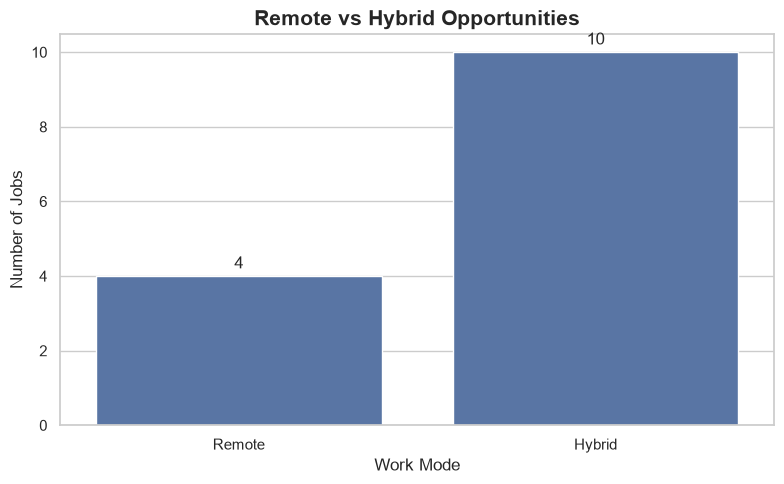

In [23]:
plt.figure(figsize=(8, 5))
ax = sns.barplot(
    x=work_mode.index,
    y=work_mode.values
)

add_values(ax)

plt.title("Remote vs Hybrid Opportunities", fontsize=15, fontweight="bold")
plt.xlabel("Work Mode")
plt.ylabel("Number of Jobs")
plt.tight_layout()
plt.show()

In [24]:
job_type = pd.Series({
    "Entry Level": (df["entry_level"] == "Yes").sum(),
    "Internship": (df["internship"] == "Yes").sum()
})

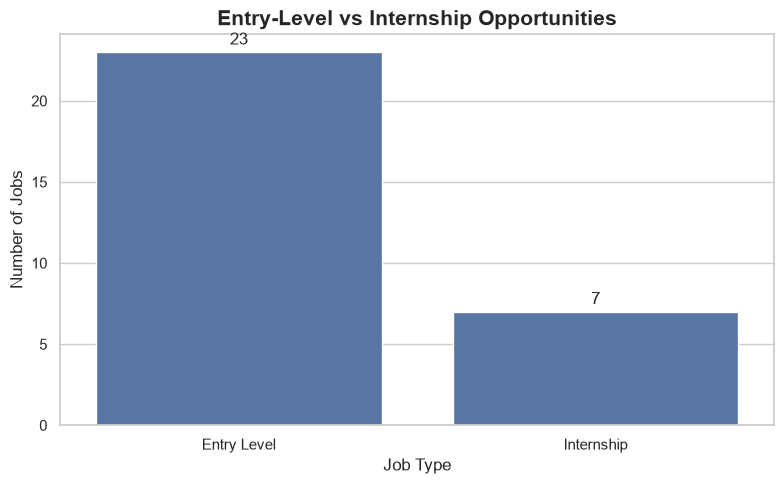

In [25]:
plt.figure(figsize=(8, 5))
ax = sns.barplot(
    x=job_type.index,
    y=job_type.values
)

add_values(ax)

plt.title("Entry-Level vs Internship Opportunities", fontsize=15, fontweight="bold")
plt.xlabel("Job Type")
plt.ylabel("Number of Jobs")
plt.tight_layout()
plt.show()

In [26]:
experience_count = df["experience"].value_counts().head(10).sort_values()

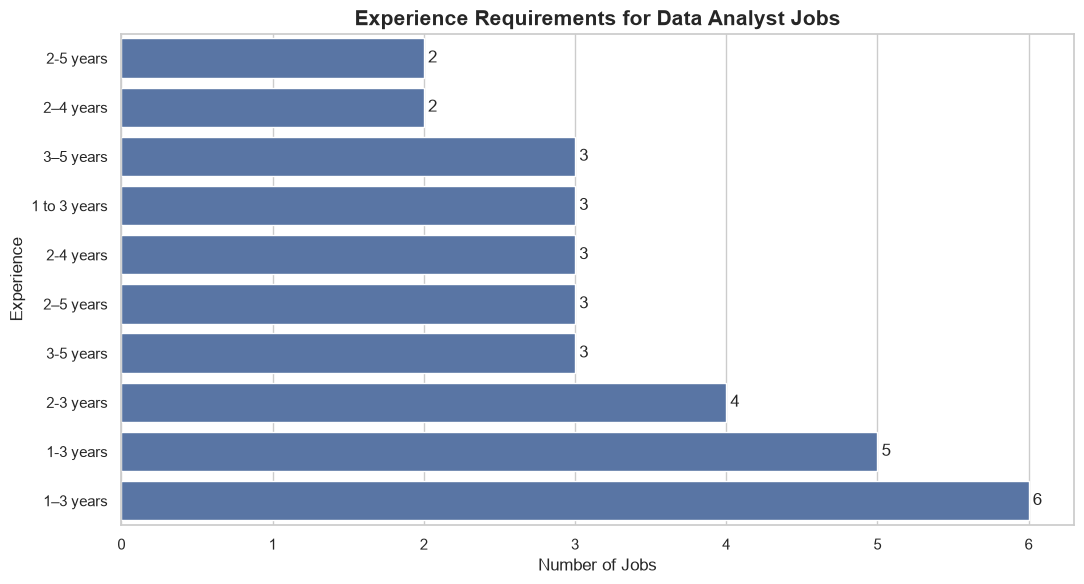

In [27]:
plt.figure(figsize=(11, 6))
ax = sns.barplot(
    x=experience_count.values,
    y=experience_count.index
)

add_values(ax)

plt.title("Experience Requirements for Data Analyst Jobs", fontsize=15, fontweight="bold")
plt.xlabel("Number of Jobs")
plt.ylabel("Experience")
plt.tight_layout()
plt.show()

In [28]:
top_companies = df["company"].value_counts().head(10).index

In [29]:
company_skill = (
    df[df["company"].isin(top_companies)]
    .groupby("company")[skills]
    .apply(lambda x: x.eq("Yes").sum())
)

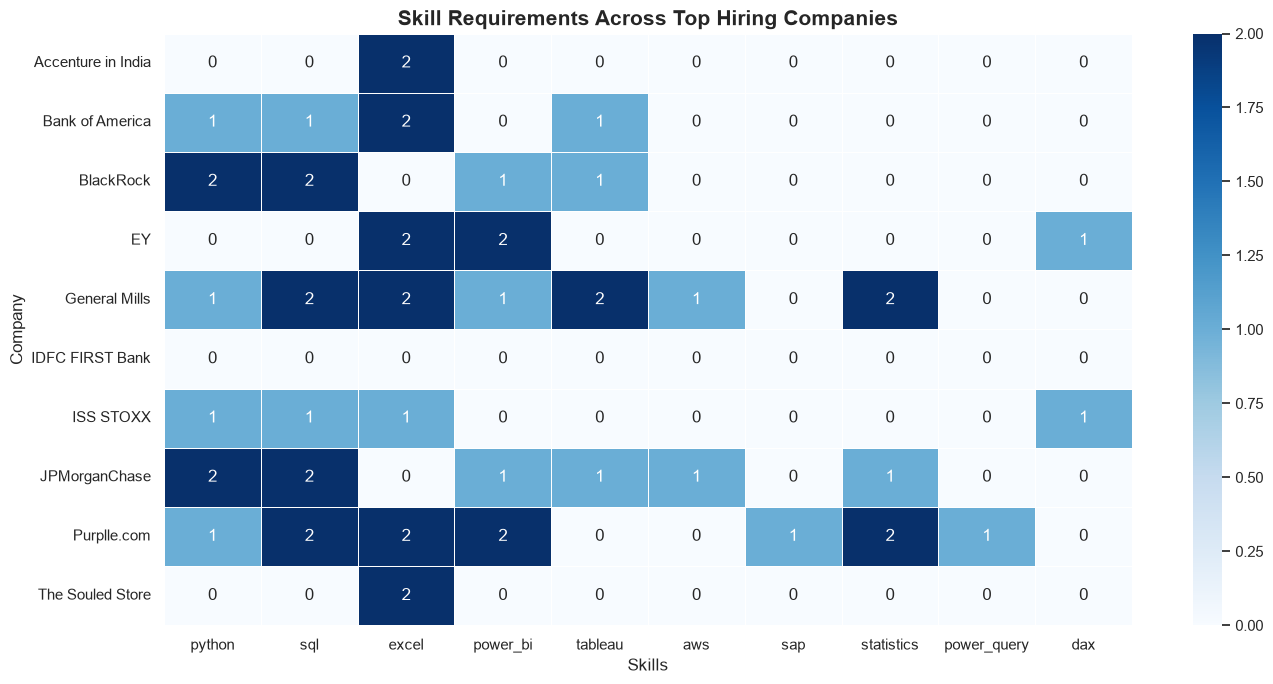

In [30]:
plt.figure(figsize=(14, 7))
sns.heatmap(
    company_skill,
    annot=True,
    fmt="g",
    cmap="Blues",
    linewidths=0.5
)

plt.title("Skill Requirements Across Top Hiring Companies", fontsize=15, fontweight="bold")
plt.xlabel("Skills")
plt.ylabel("Company")
plt.tight_layout()
plt.show()